In [3]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

# Datensatz laden
data = fetch_california_housing()

# In DataFrame umwandeln
df = pd.DataFrame(data.data, columns=data.feature_names)
df["Target"] = data.target  # Median House Value in 100.000 $

print(df.head())


   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Target  
0    -122.23   4.526  
1    -122.22   3.585  
2    -122.24   3.521  
3    -122.25   3.413  
4    -122.25   3.422  


2. Beantwortung der Fragen;
Wie alt sind die Häuser?

In [4]:
median_age = df["HouseAge"].median()
q75_age = df["HouseAge"].quantile(0.75)

print("Medianes Alter der Häuser:", median_age)
print("75. Perzentil (oberes Viertel):", q75_age)


Medianes Alter der Häuser: 29.0
75. Perzentil (oberes Viertel): 37.0


Häuser mit den meisten Räumen


In [5]:
max_rooms = df["AveRooms"].max()
most_spacious = df[df["AveRooms"] == max_rooms]

print("Maximale durchschnittliche Zimmerzahl:", max_rooms)
print("Beispielzeile:\n", most_spacious.head(1))


Maximale durchschnittliche Zimmerzahl: 141.9090909090909
Beispielzeile:
       MedInc  HouseAge    AveRooms  AveBedrms  Population  AveOccup  Latitude  \
1914   1.875      33.0  141.909091  25.636364        30.0  2.727273     38.91   

      Longitude   Target  
1914     -120.1  5.00001  


Wie viel verdienen die Bewohner der nördlichsten Häuser?

In [6]:
north_lat = df["Latitude"].max()
north_houses = df[df["Latitude"] == north_lat]

mean_income_north = north_houses["MedInc"].mean()
print("Breitengrad der nördlichsten Häuser:", north_lat)
print("Durchschnittseinkommen (×10.000 $):", mean_income_north)
print("→ Das entspricht ca.", mean_income_north * 10_000, "USD")


Breitengrad der nördlichsten Häuser: 41.95
Durchschnittseinkommen (×10.000 $): 2.0496
→ Das entspricht ca. 20496.0 USD


Wie viele Menschen wohnen in einem Haus in dem am dünnsten besiedelsten Gebiet

In [7]:
min_pop = df["Population"].min()
thin_area = df[df["Population"] == min_pop]

mean_occupancy = thin_area["AveOccup"].mean()
print("Geringste Bevölkerungszahl:", min_pop)
print("Bewohner pro Haus im dünnsten Gebiet:", mean_occupancy)


Geringste Bevölkerungszahl: 3.0
Bewohner pro Haus im dünnsten Gebiet: 0.75


3. Suche nach Missing Values oder None-Werten im Datensatz


In [8]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

# 1) Datensatz laden und in DataFrame umwandeln
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["Target"] = data.target


# 2) Fehlende Werte pro Spalte zählen
print("Fehlende Werte je Spalte:")
print(df.isnull().sum())

# 3) Gibt es überhaupt fehlende Werte?
has_missing = df.isnull().values.any()
total_missing = int(df.isnull().sum().sum())
print("\nGibt es fehlende Werte (NaN/None)?", has_missing)
print("Gesamtzahl fehlender Werte im gesamten DataFrame:", total_missing)

# 4) schnelle Strukturübersicht (zeigt 'non-null' Counts)
print("\nDataFrame-Info:")
df.info()

Fehlende Werte je Spalte:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Target        0
dtype: int64

Gibt es fehlende Werte (NaN/None)? False
Gesamtzahl fehlender Werte im gesamten DataFrame: 0

DataFrame-Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


4. missing values ersetzen --> es gibt keine

5. Streudiagramm zwischen Einkommen und Verkaufswert der Häuser. Berechnen Sie auch die Korrelation.

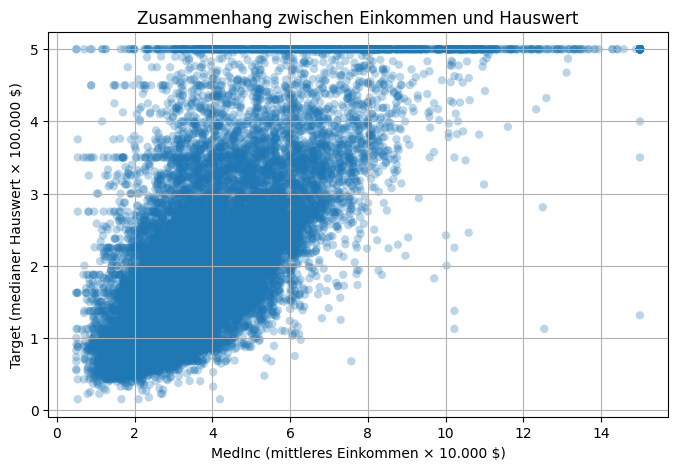

Korrelation zwischen Einkommen und Hauswert: 0.688


In [9]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import matplotlib.pyplot as plt

# 1) Datensatz laden
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["Target"] = data.target  # medianer Hauswert (×100.000 $)

# 2) Streudiagramm zwischen Einkommen und Hauswert
plt.figure(figsize=(8, 5))
plt.scatter(df["MedInc"], df["Target"], alpha=0.3, edgecolor="none")
plt.title("Zusammenhang zwischen Einkommen und Hauswert")
plt.xlabel("MedInc (mittleres Einkommen × 10.000 $)")
plt.ylabel("Target (medianer Hauswert × 100.000 $)")
plt.grid(True)
plt.show()

# 3) Korrelation berechnen (Pearson)
correlation = df["MedInc"].corr(df["Target"])
print(f"Korrelation zwischen Einkommen und Hauswert: {correlation:.3f}")


6. Regressionsanalyse; Teil A

LINEARE REGRESSION: Hauswert = β0 + β1 * Einkommen

β0 (Achsenabschnitt): 0.451
β1 (Steigung):        0.418
Bestimmtheitsmaß R²:  0.473


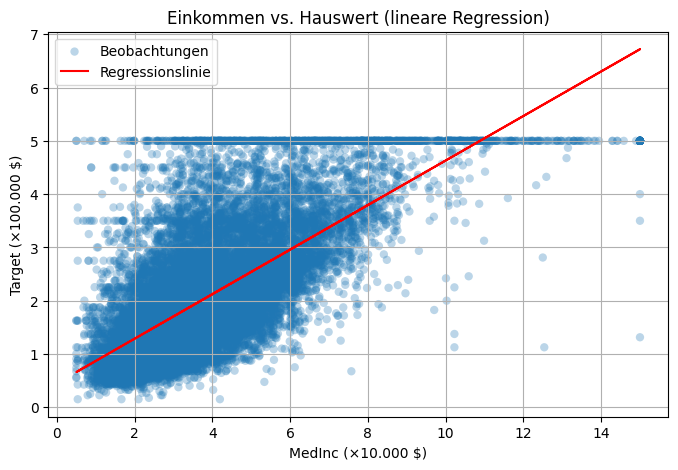

In [10]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

# 1) Datensatz laden
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["Target"] = data.target  # medianer Hauswert (×100.000 $)

# 2) Eingangs- und Zielvariable definieren
X = df[["MedInc"]]  # Einkommen (×10.000 $)
y = df["Target"]  # Hauswert (×100.000 $)

# 3) Lineare Regression trainieren
model = LinearRegression()
model.fit(X, y)

# 4) Kennwerte berechnen
r2 = model.score(X, y)
slope = model.coef_[0]
intercept = model.intercept_

print("LINEARE REGRESSION: Hauswert = β0 + β1 * Einkommen\n")
print(f"β0 (Achsenabschnitt): {intercept:.3f}")
print(f"β1 (Steigung):        {slope:.3f}")
print(f"Bestimmtheitsmaß R²:  {r2:.3f}")

# 5) Streudiagramm mit Regressionslinie
plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.3, edgecolor="none", label="Beobachtungen")
plt.plot(X, model.predict(X), color="red", label="Regressionslinie")
plt.title("Einkommen vs. Hauswert (lineare Regression)")
plt.xlabel("MedInc (×10.000 $)")
plt.ylabel("Target (×100.000 $)")
plt.legend()
plt.grid(True)
plt.show()


6. Regressionsanalyse; Teil B


🔹 REGRESSION – ALLE DATEN
β₀ (Intercept): 0.451
β₁ (Steigung):  0.418
R²:             0.473

REGRESSION – OHNE EXTREME (mittlere 80%)
β₀ (Intercept): 0.830
β₁ (Steigung):  0.294
R²:             0.312


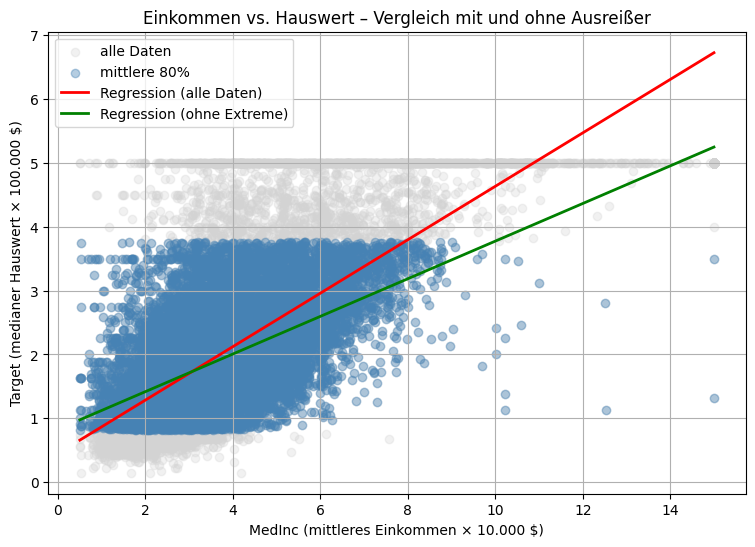

In [15]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1) Datensatz laden
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["Target"] = data.target  # medianer Hauswert (×100.000 $)

# 2) Grundmodell (mit allen Daten)
X = df[["MedInc"]]
y = df["Target"]

model_full = LinearRegression()
model_full.fit(X, y)

r2_full = model_full.score(X, y)
slope_full = model_full.coef_[0]
intercept_full = model_full.intercept_

print("🔹 REGRESSION – ALLE DATEN")
print(f"β₀ (Intercept): {intercept_full:.3f}")
print(f"β₁ (Steigung):  {slope_full:.3f}")
print(f"R²:             {r2_full:.3f}")

# 3) Extremwerte (oberste & unterste 10%) entfernen
lower = df["Target"].quantile(0.10)
upper = df["Target"].quantile(0.90)
df_trim = df[(df["Target"] >= lower) & (df["Target"] <= upper)]

X_trim = df_trim[["MedInc"]]
y_trim = df_trim["Target"]

model_trim = LinearRegression()
model_trim.fit(X_trim, y_trim)

r2_trim = model_trim.score(X_trim, y_trim)
slope_trim = model_trim.coef_[0]
intercept_trim = model_trim.intercept_

print("\nREGRESSION – OHNE EXTREME (mittlere 80%)")
print(f"β₀ (Intercept): {intercept_trim:.3f}")
print(f"β₁ (Steigung):  {slope_trim:.3f}")
print(f"R²:             {r2_trim:.3f}")

# 4) Vergleichsgrafik beider Regressionen
plt.figure(figsize=(9,6))
plt.scatter(df["MedInc"], df["Target"], color="lightgray", alpha=0.3, label="alle Daten")
plt.scatter(df_trim["MedInc"], df_trim["Target"], color="steelblue", alpha=0.4, label="mittlere 80%")

# Linien zeichnen – jetzt mit Spaltennamen
x_vals = pd.DataFrame(sorted(df["MedInc"].unique()), columns=["MedInc"])
plt.plot(x_vals, model_full.predict(x_vals), color="red", lw=2, label="Regression (alle Daten)")
plt.plot(x_vals, model_trim.predict(x_vals), color="green", lw=2, label="Regression (ohne Extreme)")

plt.title("Einkommen vs. Hauswert – Vergleich mit und ohne Ausreißer")
plt.xlabel("MedInc (mittleres Einkommen × 10.000 $)")
plt.ylabel("Target (medianer Hauswert × 100.000 $)")
plt.legend()
plt.grid(True)
plt.show()

